# Curated Income Analysis — Exactly 5 Visualizations

In [1]:

# Load dataset
column_names = [
    'age', 'workclass', 'fnlwgt', 'education', 'education_num',
    'marital_status', 'occupation', 'relationship', 'race', 'sex',
    'capital_gain', 'capital_loss', 'hours_per_week', 'native_country', 'income'
]
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data'
df = pd.read_csv(url, header=None, names=column_names, na_values=' ?')
df.dropna(inplace=True)
df['income'] = df['income'].str.strip()

Missing values per column:
 age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
income            0
dtype: int64


In [ ]:
# === Helper Functions for Plotting ===
    """Plot proportion of each category in a column split by income group."""
    low = low_income[column].value_counts(normalize=True).sort_index()
    high = high_income[column].value_counts(normalize=True).sort_index()
    comp_df = pd.DataFrame({'<=50K': low, '>50K': high}).fillna(0)
    comp_df.plot(kind='bar', figsize=(10, 5))
    plt.title(f'{title} by Income Group')
    plt.ylabel('Proportion')
    plt.xticks(rotation=45)
    plt.grid(axis='y')
    plt.tight_layout()
    plt.show()

    """Plot histogram of a numeric column split by income group."""
    plt.figure(figsize=(8,5))
    sns.histplot(data=df, x=column, hue='income', kde=False, stat='count', common_norm=False, bins=30)
    plt.title(title)
    plt.tight_layout()
    plt.show()

In [ ]:
# === Create Income Group DataFrames ===
low_income = df[df['income'] == '<=50K']
high_income = df[df['income'] == '>50K']

In [2]:
# === 5. VISUALIZATION FUNCTIONS ===
    low = low_income[column].value_counts(normalize=True).sort_index()
    high = high_income[column].value_counts(normalize=True).sort_index()
    comp_df = pd.DataFrame({'<=50K': low, '>50K': high}).fillna(0)
    comp_df.plot(kind='bar', figsize=(10, 5))
    plt.title(f'{title} by Income Group')
    plt.ylabel('Proportion')
    plt.xticks(rotation=45)
    plt.grid(axis='y')
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 5))
    sns.histplot(data=df, x=column, hue='income', kde=True, bins=bins)
    plt.title(title)
    plt.xlabel(column)
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()

In [3]:
# === 4. CREATE INCOME GROUPS ===
low_income = df[df['income'] == '<=50K']
high_income = df[df['income'] == '>50K']

# === 5. VISUALIZATION FUNCTIONS ===
    low = low_income[column].value_counts(normalize=True).sort_index()
    high = high_income[column].value_counts(normalize=True).sort_index()
    comp_df = pd.DataFrame({'<=50K': low, '>50K': high}).fillna(0)
    comp_df.plot(kind='bar', figsize=(10, 5))
    plt.title(f'{title} by Income Group')
    plt.ylabel('Proportion')
    plt.xticks(rotation=45)
    plt.grid(axis='y')
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 5))
    sns.histplot(data=df, x=column, hue='income', kde=True, bins=bins)
    plt.title(title)
    plt.xlabel(column)
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()

## 1) Age Distribution by Income (Kept As-Is)

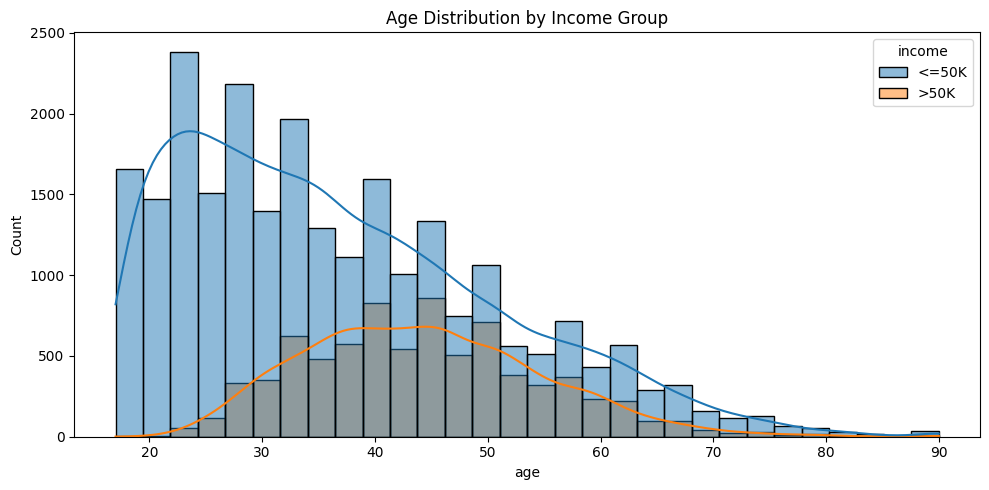

In [4]:
# === 6. AGE DISTRIBUTION ===
plot_numeric_distribution('age', 'Age Distribution by Income Group')

## 2) Education Level vs Income (Only Bar Chart)

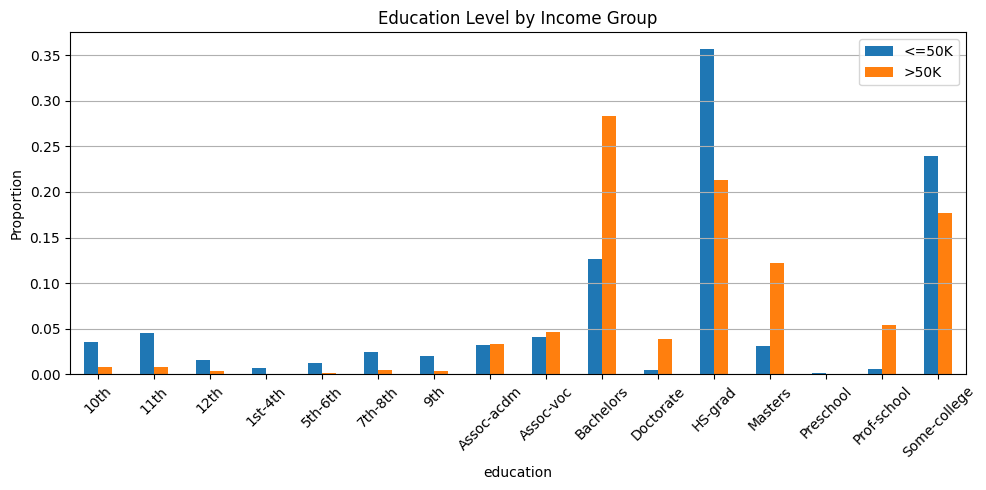

In [5]:
# === 7. EDUCATION COMPARISON ===
plot_categorical_distribution('education', 'Education Level')

## 3) Pay Disparity: >$50K Rate by Race × Gender (Heatmap)

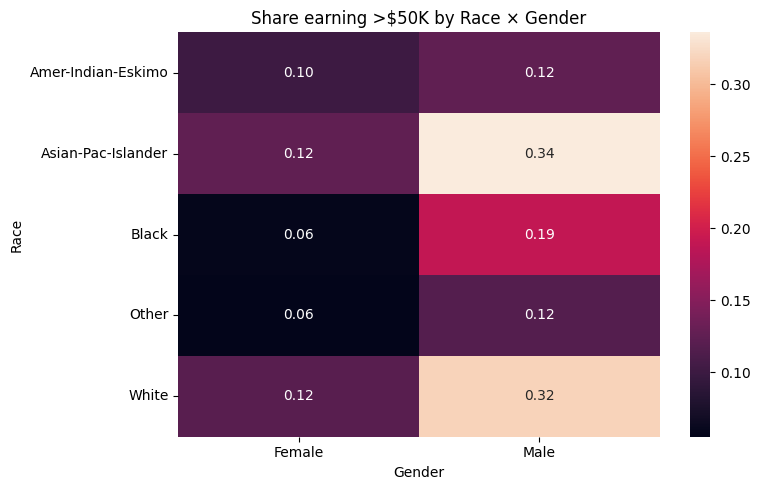

In [6]:

# Multivariate: Pay disparity by race and gender, measured as % earning >50K

# Clean income labels
df['income'] = df['income'].str.strip()

# Compute rate of >50K
pivot = (df.assign(income_gt50 = (df['income'] == '>50K').astype(int))
           .pivot_table(values='income_gt50', index='race', columns='sex', aggfunc='mean'))

plt.figure(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt=".2f")
plt.title("Share earning >$50K by Race × Gender")
plt.xlabel("Gender")
plt.ylabel("Race")
plt.tight_layout()
plt.show()

## 4) Hours Worked vs Age by Income (Scatter)

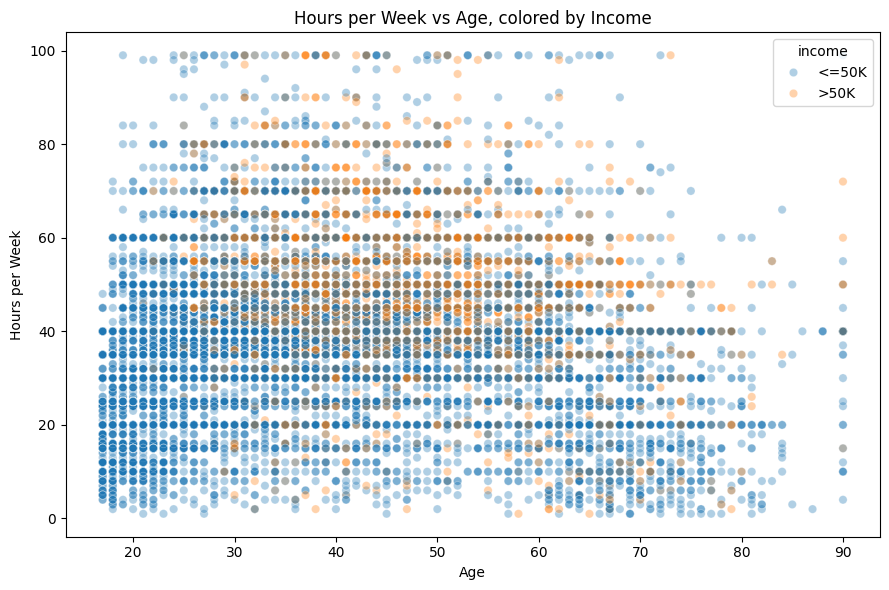

In [7]:

# Multivariate: Two numerical predictors against income

plt.figure(figsize=(9,6))
sns.scatterplot(data=df, x='age', y='hours_per_week', hue='income', alpha=0.35)
plt.title("Hours per Week vs Age, colored by Income")
plt.xlabel("Age")
plt.ylabel("Hours per Week")
plt.tight_layout()
plt.show()

## 5) Marital Status × Income (Mosaic)

<Figure size 800x600 with 0 Axes>

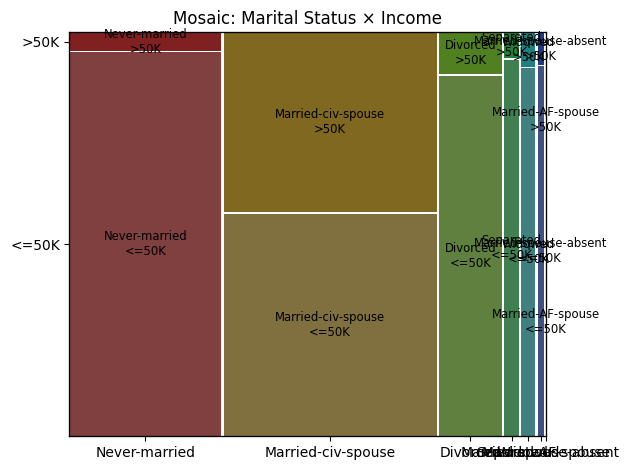

In [8]:


counts = df[['marital_status', 'income']].value_counts().reset_index(name="count")
data = {(row['marital_status'], row['income']): int(row['count']) for _, row in counts.iterrows()}
plt.figure(figsize=(8,6))
mosaic(data, title='Mosaic: Marital Status × Income')
plt.tight_layout()
plt.show()

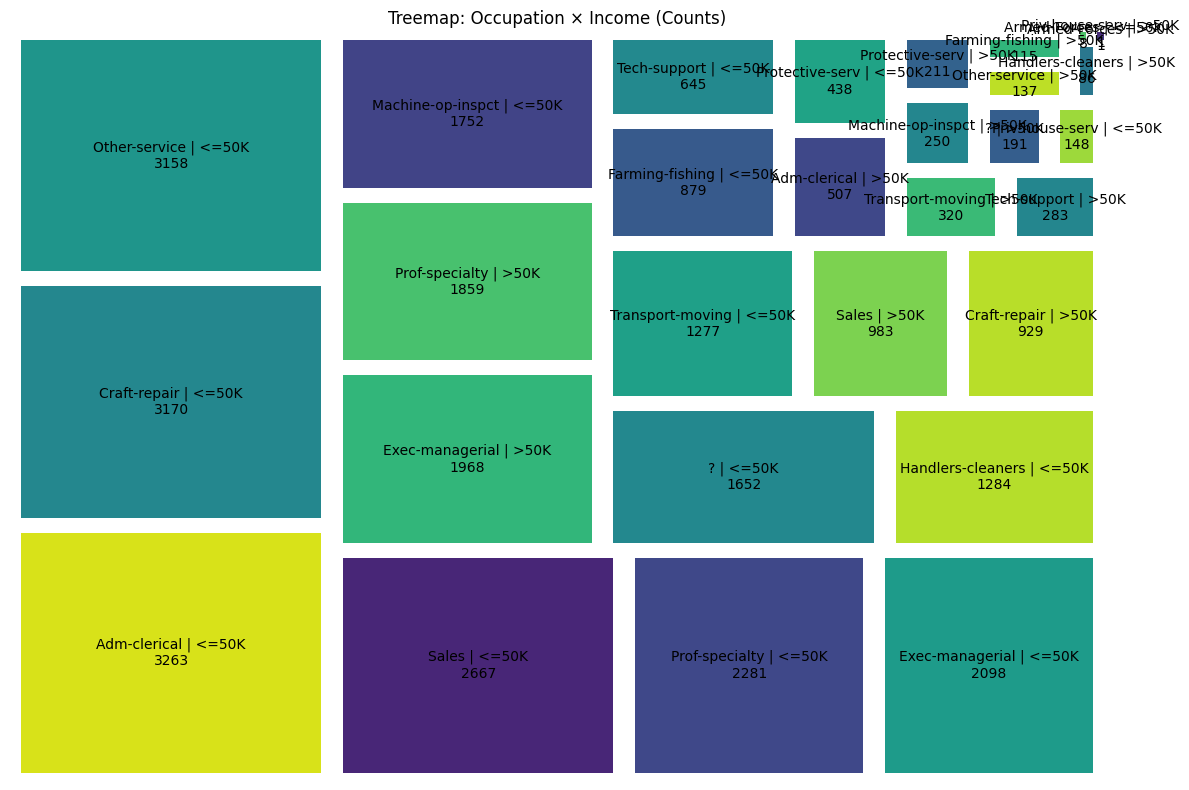

In [10]:
grp = (
    df.groupby(['occupation', 'income'])
      .size()
      .reset_index(name='count')
      .sort_values('count', ascending=False)
)

labels = [f"{occ} | {inc}\n{cnt}" for occ, inc, cnt in zip(grp['occupation'], grp['income'], grp['count'])]
sizes = grp['count'].to_numpy()

plt.figure(figsize=(12, 8))
squarify.plot(sizes=sizes, label=labels, pad=True)
plt.axis('off')
plt.title("Treemap: Occupation × Income (Counts)")
plt.tight_layout()
plt.show()

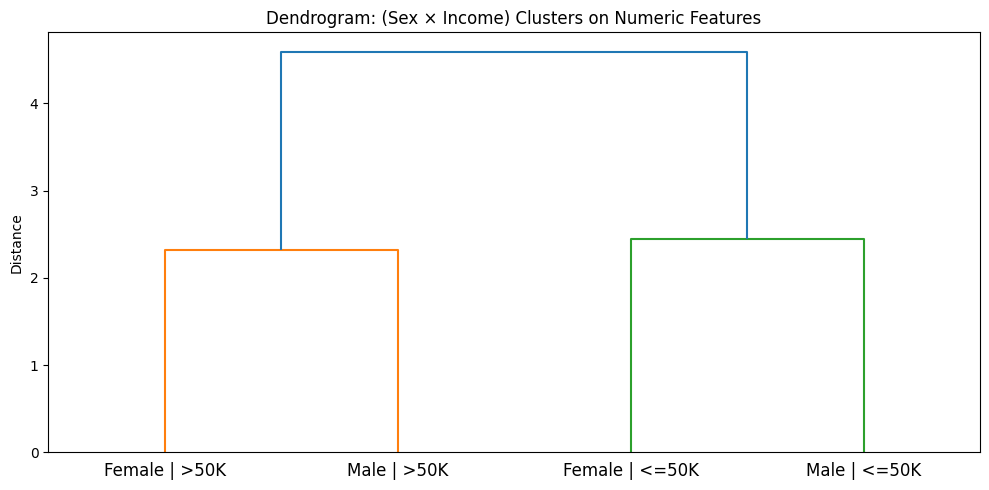

In [11]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
grouped = df.groupby(['sex', 'income'])[numeric_cols].mean().dropna()
X = (grouped - grouped.mean()) / grouped.std(ddof=0).replace(0, 1.0)

Z = linkage(X, method='average', metric='euclidean')

plt.figure(figsize=(10, 5))
dendrogram(Z, labels=[f"{sex} | {income}" for sex, income in grouped.index])
plt.title("Dendrogram: (Sex × Income) Clusters on Numeric Features")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()